# Info

The following work analyzes the database: student-depression-dataset. Focusing on the population of students who are exclusively studying. The corresponding dashboards will be uploaded to this same repository.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset

In [2]:
data = pd.read_csv(r'/kaggle/input/student-depression-dataset/student_depression_dataset.csv')
data.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

# 2. Data Cleaning

## 2.1 Missing values

In [4]:
data.isnull().sum() #Revisamo si hay valores nulos

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

## 2.2 Duplicated values

In [5]:
data.duplicated().any() #Revisamos si hay valores duplicados

False

## 2.3 Convert Data

We will convert categorical data with numeric information ('Sleep Duration') and those with numeric information but are of the object type.

In [6]:
data['Financial Stress'].unique()

array(['1.0', '2.0', '5.0', '3.0', '4.0', '?'], dtype=object)

We will replace the '?' value with the average.

In [7]:
    
data['Financial Stress'] = pd.to_numeric(data['Financial Stress'], errors='coerce').astype('float32')

mean_value = data['Financial Stress'].mean()
data['Financial Stress'] = data['Financial Stress'].fillna(mean_value)

In [8]:
data['Sleep Duration'].unique()

array(["'5-6 hours'", "'Less than 5 hours'", "'7-8 hours'",
       "'More than 8 hours'", 'Others'], dtype=object)

We will replace with the mean of the intervals.

In [9]:
sleep_hours_map = {
    "'5-6 hours'": 5.5,
    "'Less than 5 hours'": 4.5,
    "'7-8 hours'": 7.5,
    "'More than 8 hours'": 8.5,
}

data['Sleep Duration'] = data['Sleep Duration'].map(sleep_hours_map)

mean_sleep = data['Sleep Duration'].mean()
data['Sleep Duration'] = data['Sleep Duration'].fillna(mean_sleep)

## 2.4 Data optimization

In [10]:
info1 = data.memory_usage(deep=True)

In [11]:
data = (data.astype({
    'id': 'uint32',
    'Gender':'category',
    'Age':'uint8',
    'City':'category',
    'Profession':'category',
    'Academic Pressure':'uint8',
    'Work Pressure':'uint8',
    'CGPA':'uint8',
    'Study Satisfaction':'uint8',
    'Job Satisfaction':'uint8',
    'Sleep Duration':'float32',
    'Dietary Habits':'category',
    'Degree':'category',
    'Have you ever had suicidal thoughts ?':'category',
    'Work/Study Hours':'uint8',
    'Financial Stress':'uint8',
    'Family History of Mental Illness':'category',
    'Depression':'uint8'   
}))

In [12]:
print('Before: \n',info1)
print('\nAfter: \n', data.memory_usage(deep=True))

Before: 
 Index                                        132
id                                        223208
Gender                                   1726669
Age                                       223208
City                                     1786510
Profession                               1785768
Academic Pressure                         223208
Work Pressure                             223208
CGPA                                      223208
Study Satisfaction                        223208
Job Satisfaction                          223208
Sleep Duration                            223208
Dietary Habits                           1816207
Degree                                   1738599
Have you ever had suicidal thoughts ?    1663815
Work/Study Hours                          223208
Financial Stress                          111604
Family History of Mental Illness         1659662
Depression                                223208
dtype: int64

After: 
 Index                               

# 3. Exploratory Data Analysis (EDA)

## 3.1 Definition of the population.

In [13]:
data['Profession'].value_counts()

Profession
Student                     27870
Architect                       8
Teacher                         6
'Digital Marketer'              3
'Content Writer'                2
Chef                            2
Doctor                          2
Pharmacist                      2
'Civil Engineer'                1
'Educational Consultant'        1
'UX/UI Designer'                1
Entrepreneur                    1
Lawyer                          1
Manager                         1
Name: count, dtype: int64

Our analysis will focus on students who are exclusively studying.

In [14]:
students = data.loc[data['Profession']=='Student'].copy()
students.drop('id', axis=1,inplace=True)

## 3.2 Distribution of the target variable.

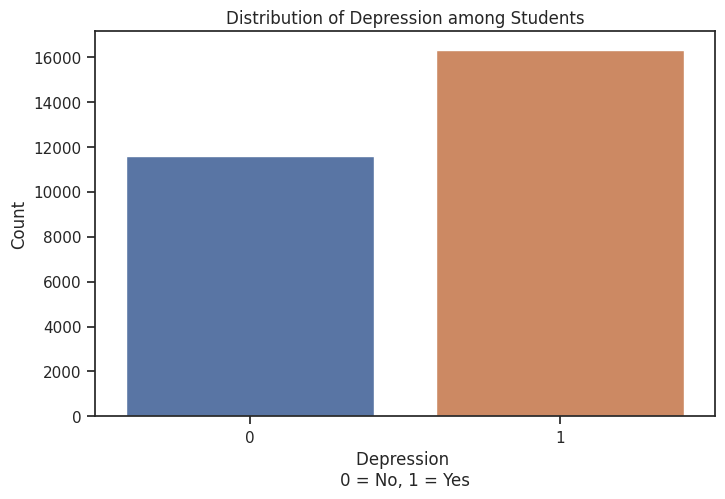

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Depression', data=students)
plt.title("Distribution of Depression among Students")
plt.xlabel("Depression \n0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

## 3.3 Numerical Variables.

### 3.3.1 Statistics.

In [16]:
students.describe(include='number')

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Work/Study Hours,Financial Stress,Depression
count,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000
mean,25.821134,3.140617,0.000431,7.134266,2.943559,0.000682,6.378788,7.157948,3.139505,0.585145
std,4.906574,1.381640,0.044016,1.435413,1.361209,0.044419,1.590179,3.707180,1.437212,0.492706
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000,0.000000,1.000000,0.000000
25%,21.000000,2.000000,0.000000,6.000000,2.000000,0.000000,4.500000,4.000000,2.000000,0.000000
50%,25.000000,3.000000,0.000000,7.000000,3.000000,0.000000,5.500000,8.000000,3.000000,1.000000
75%,30.000000,4.000000,0.000000,8.000000,4.000000,0.000000,7.500000,10.000000,4.000000,1.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,8.500000,12.000000,5.000000,1.000000


### 3.3.2 Distributions.

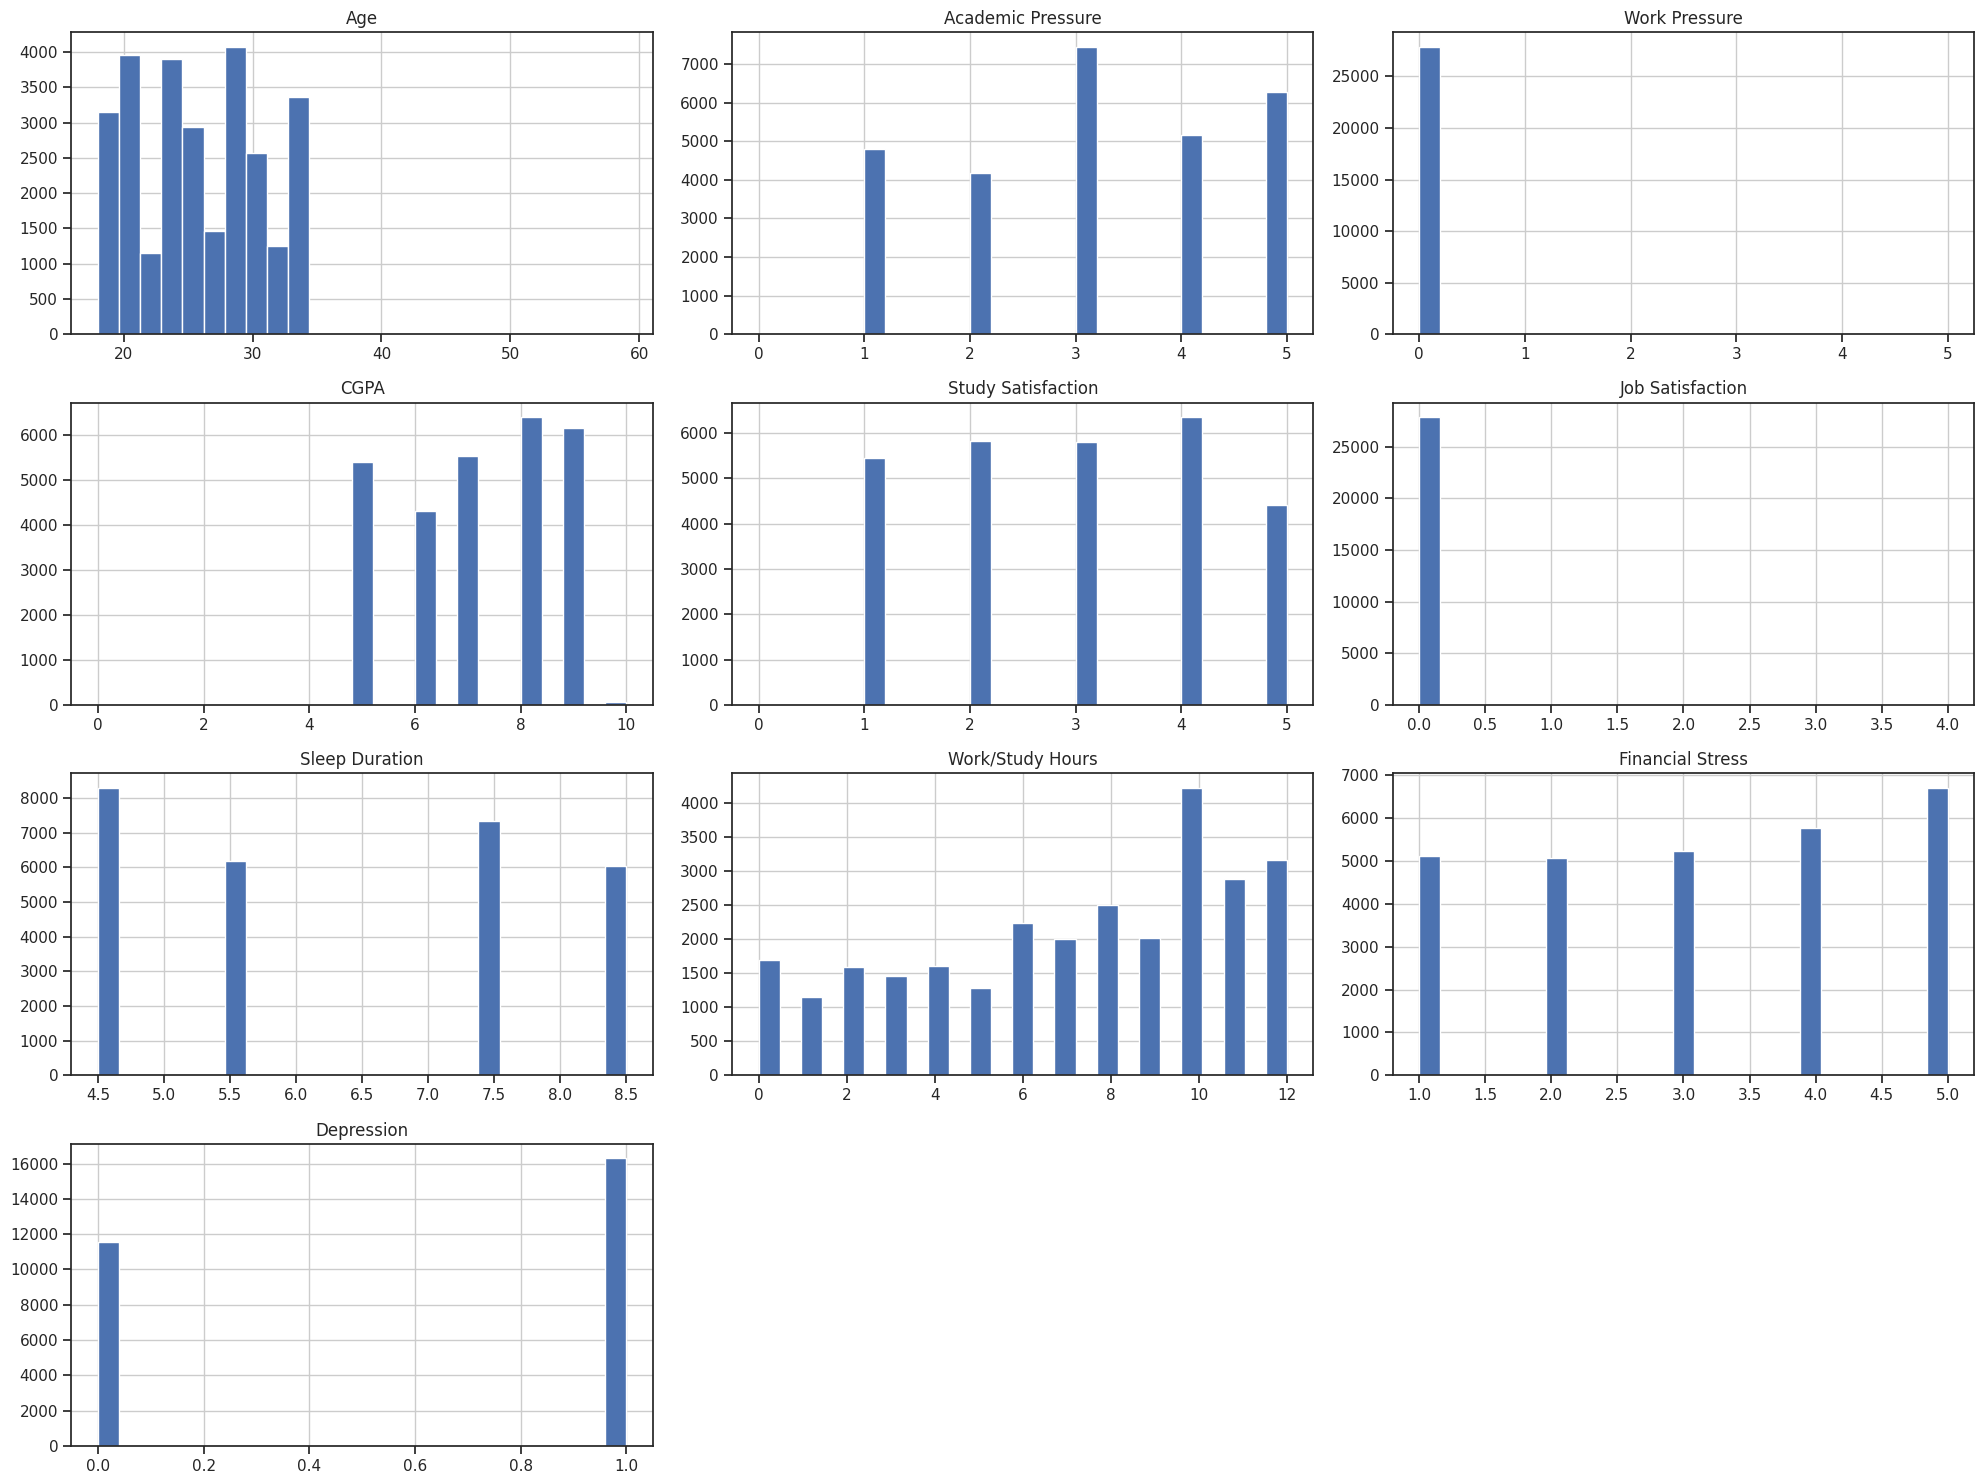

In [17]:
students.hist(bins=25,figsize=(20,15))
plt.tight_layout()
plt.show()

### 3.3.3 Correlation Matrix.

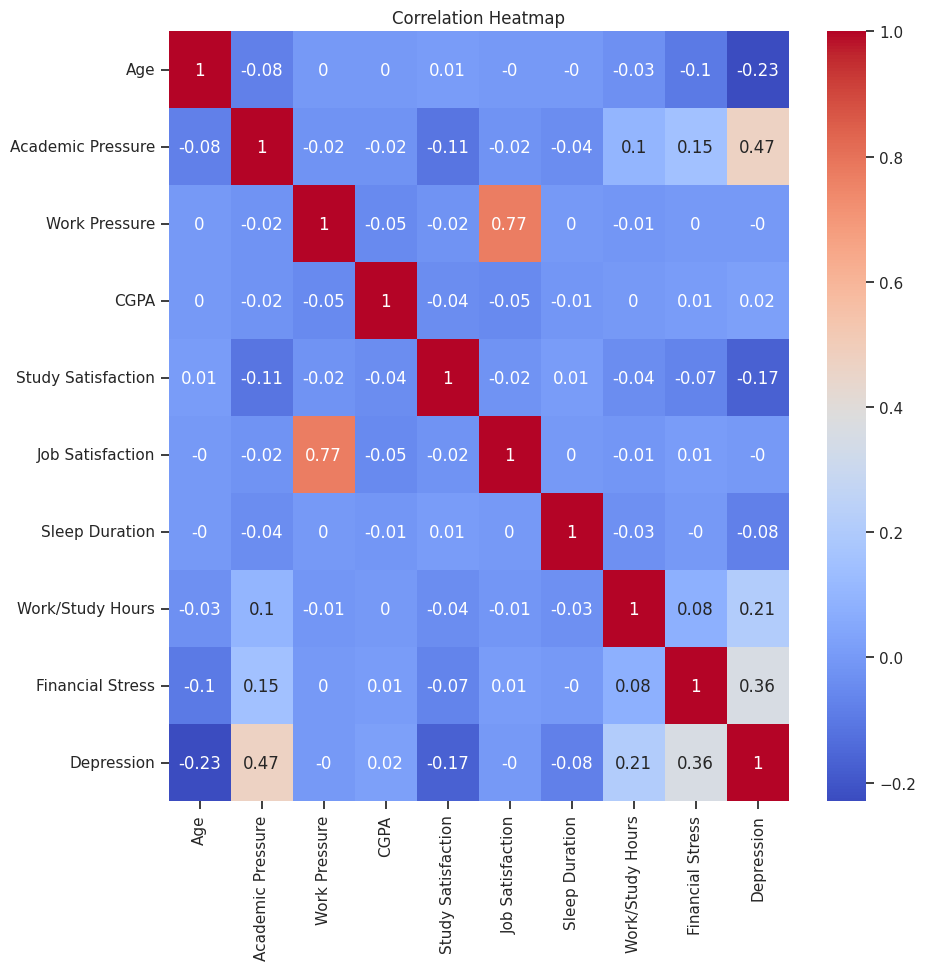

In [18]:
plt.figure(figsize=(10,10))
matrix_corr = students.corr(numeric_only=True).round(2)

sns.heatmap(matrix_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
matrix_corr['Depression'].sort_values(ascending=False)

Depression            1.00
Academic Pressure     0.47
Financial Stress      0.36
Work/Study Hours      0.21
CGPA                  0.02
Work Pressure        -0.00
Job Satisfaction     -0.00
Sleep Duration       -0.08
Study Satisfaction   -0.17
Age                  -0.23
Name: Depression, dtype: float64

## 3.4 Percentage of women and men.

In [20]:
students['Gender'].value_counts(normalize=True).round(2)*100

Gender
Male      56.0
Female    44.0
Name: proportion, dtype: float64

## 3.5 Which gender is more likely to experience depression?

In [21]:
total_G = students.Gender.shape[0]

Men_Dep = students.loc[(students['Gender']=='Male') & ((students['Depression']== 1))].shape[0]

Women_Dep = students.loc[(students['Gender']=='Female') & ((students['Depression']== 1))].shape[0]

print(f'Male: {((Men_Dep/total_G)*100):.0f}%\nFemale: {((Women_Dep/total_G)*100):.0f}%')

Male: 33%
Female: 26%


## 3.6 Gender distribution.

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


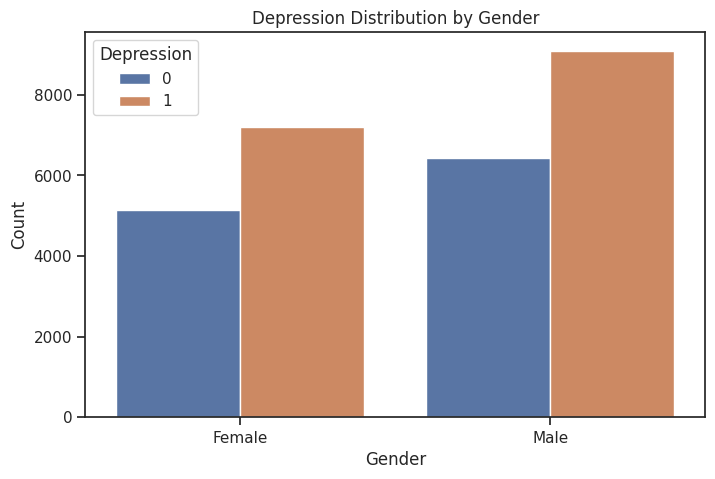

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', hue='Depression', data=students, palette='deep')
plt.title("Depression Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Depression")
plt.show()

## 3.7 Which age group presents more cases of depression?

In [23]:
students.groupby('Age')['Depression'].sum().sort_values(ascending =False).head(5)

Age
20    1579
24    1506
28    1306
18    1216
21    1166
Name: Depression, dtype: uint64

## 3.7.1 Percentage of students with depression within each age.

In [24]:
depression_rate = students.groupby('Age')['Depression'].mean() * 100
depression_rate.sort_values(ascending =False).head(5)

Age
41    100.000000
18     76.622558
20     70.585606
19     70.512821
21     67.672664
Name: Depression, dtype: float64

## 3.8 Which dietary habit shows the fewest cases of depression?

In [25]:
students.groupby('Dietary Habits')['Depression'].sum().sort_values(ascending=True)

/tmp/ipykernel_13/3399393793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  students.groupby('Dietary Habits')['Depression'].sum().sort_values(ascending=True)


Dietary Habits
Others          8
Healthy      3463
Moderate     5548
Unhealthy    7289
Name: Depression, dtype: uint64

# 4. Logistic Regression Model.

This time, we will train our model using the three most strongly correlated variables.

In [26]:
col = ['Academic Pressure','Financial Stress','Age']

X = students[col].copy()
Y = students['Depression'].copy()

#Estandarizacion
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=col)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

LR Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72      2347
           1       0.79      0.84      0.81      3227

    accuracy                           0.78      5574
   macro avg       0.77      0.77      0.77      5574
weighted avg       0.78      0.78      0.78      5574



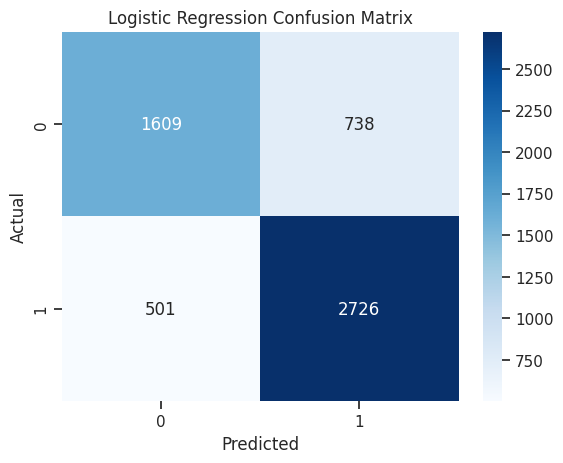

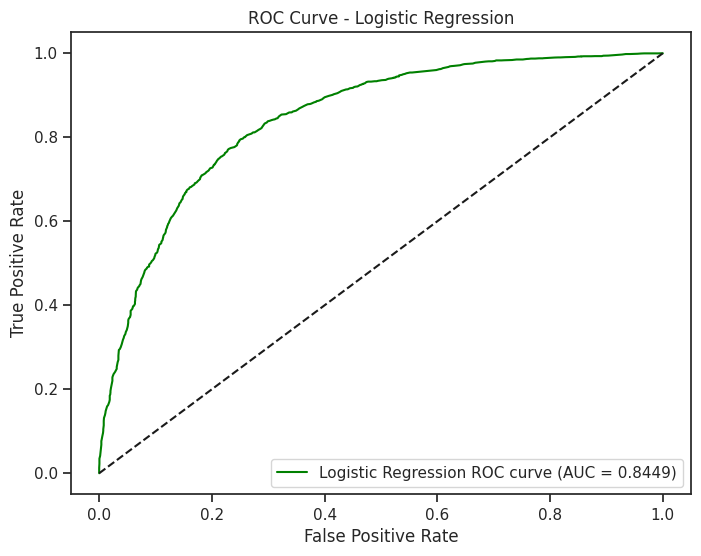

In [27]:
# Logistic Regression
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, Y_train)

# Predictions and evaluation
Y_pred = log_model.predict(X_test)
print("LR Report:")
print(classification_report(Y_test, Y_pred))

# Confusion matrix
CM = confusion_matrix(Y_test, Y_pred)
sns.heatmap(CM, annot=True, fmt="d", cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
Y_prob = log_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
roc_auc_log = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression ROC curve (AUC = {roc_auc_log:.4f})', color='green')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# Conclusions


- In general, men suffer from depression more frequently than women.

- Habits considered healthy, such as eating well and sleeping well, are associated with lower rates of depression.

- Age groups between 18-28 years show higher rates of depression, with those aged 18-20 being the most vulnerable.

# Model:

- The model is more efficient at identifying individuals with depression.

- The model's performance is good, with an AUC (Area Under the Curve) of 0.8449.